# Experiment 3.0.3 — L3 bottleneck ablation

Analysis-only notebook. Training, checkpoint selection, frozen probes, and firing-rate extraction are executed by the Slurm pipeline. This notebook only reads finalized CSV artifacts, summarizes the results, and plots comparisons.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ARTIFACT_ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_3_0_3_l3_bottleneck_ablation' / 'l3_bottleneck_v1'
print('Repository root:', REPO_ROOT)
print('Artifact root:', ARTIFACT_ROOT)


Repository root: /home/zhaolongwei_umass_edu/projects/writingRing
Artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_0_3_l3_bottleneck_ablation/l3_bottleneck_v1


In [2]:
files = {
    'architectures': 'experiment_3_0_3_architectures.csv',
    'native': 'experiment_3_0_3_native_results.csv',
    'native_summary': 'experiment_3_0_3_native_summary.csv',
    'history': 'experiment_3_0_3_history.csv',
    'layer_probes': 'experiment_3_0_3_layer_probes.csv',
    'layer_probe_summary': 'experiment_3_0_3_layer_probe_summary.csv',
    'subgroup_probes': 'experiment_3_0_3_tau_subgroup_probes.csv',
    'subgroup_probe_summary': 'experiment_3_0_3_tau_subgroup_probe_summary.csv',
    'firing': 'experiment_3_0_3_firing_rates.csv',
    'firing_summary': 'experiment_3_0_3_firing_rate_summary.csv',
    'diagnostics': 'experiment_3_0_3_diagnostics.csv',
    'diagnostic_summary': 'experiment_3_0_3_diagnostic_summary.csv',
}
missing = [name for name in files.values() if not (ARTIFACT_ROOT / name).exists()]
if missing:
    raise FileNotFoundError('Run/finalize Experiment 3.0.3 first. Missing: ' + ', '.join(missing))
frames = {key: pd.read_csv(ARTIFACT_ROOT / filename) for key, filename in files.items()}
architectures = frames['architectures']
native = frames['native']
native_summary = frames['native_summary']
history = frames['history']
layer_probes = frames['layer_probes']
layer_probe_summary = frames['layer_probe_summary']
subgroup_probes = frames['subgroup_probes']
subgroup_probe_summary = frames['subgroup_probe_summary']
firing = frames['firing']
firing_summary = frames['firing_summary']
diagnostics = frames['diagnostics']
diagnostic_summary = frames['diagnostic_summary']


## Architecture table


In [3]:
display(architectures[['architecture','label','description','last_layer','layer','layer_width','shifts']].drop_duplicates())


,architecture,label,description,last_layer,layer,layer_width,shifts
0,A,3.0.2-C baseline,Reuse 3.0.2-C: 64-neuron single-tau L3,L3,L1,128,"2,3,4"
3,A,3.0.2-C baseline,Reuse 3.0.2-C: 64-neuron single-tau L3,L3,L2,128,"2,3,4"
6,A,3.0.2-C baseline,Reuse 3.0.2-C: 64-neuron single-tau L3,L3,L3,64,3
7,B,No-L3,Remove L3 and attach the task head directly to L2,L2,L1,128,"2,3,4"
10,B,No-L3,Remove L3 and attach the task head directly to L2,L2,L2,128,"2,3,4"
13,C,Width128,Keep single-tau shift3 L3 but remove 128->64 w...,L3,L1,128,"2,3,4"
16,C,Width128,Keep single-tau shift3 L3 but remove 128->64 w...,L3,L2,128,"2,3,4"
19,C,Width128,Keep single-tau shift3 L3 but remove 128->64 w...,L3,L3,128,3
20,D,MultiTau64,Keep L3 width 64 but remove single-tau tempora...,L3,L1,128,"2,3,4"
23,D,MultiTau64,Keep L3 width 64 but remove single-tau tempora...,L3,L2,128,"2,3,4"


## Native test balanced accuracy


objective,fixed250_sequence_ce,relative10_sequence_ce,timestep_ce
architecture,,,
A,0.490975,0.561331,0.462039
B,0.497001,0.676388,0.492621
C,0.484216,0.600386,0.445625
D,0.467756,0.617787,0.447034
E,0.488971,0.584645,0.413458


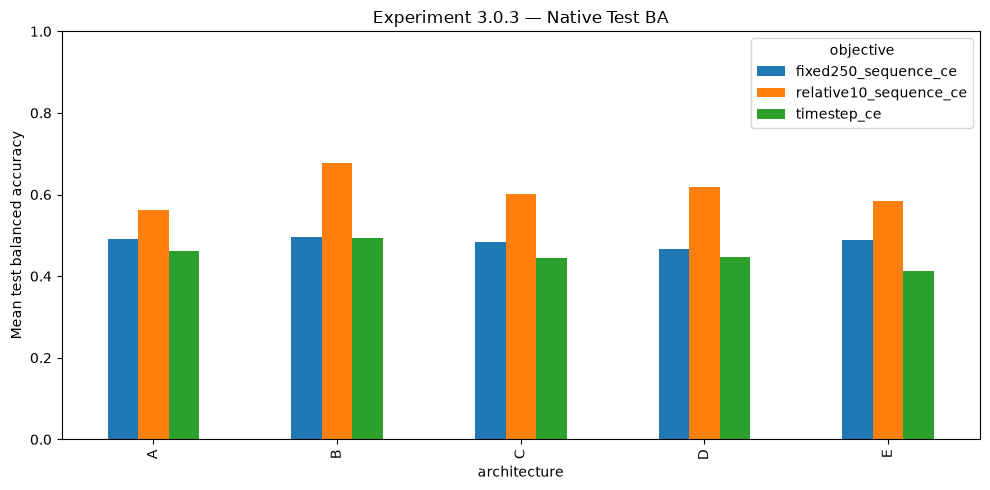

In [4]:
native_table = native_summary.pivot(index='architecture', columns='objective', values='mean_test_balanced_accuracy')
display(native_table)
ax = native_table.plot(kind='bar', figsize=(10,5))
ax.set_ylabel('Mean test balanced accuracy')
ax.set_title('Experiment 3.0.3 — Native Test BA')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Layer-wise fixed250 frozen linear probes

Use these plots to see whether L3 preserves, improves, or degrades the strong L2 representation. Architecture B has no L3.


layer,L1,L2,L3
architecture,,,
A,0.487007,0.541018,0.523881
B,0.474328,0.491647,NaN
C,0.516694,0.510963,0.520090
D,0.480699,0.492868,0.500419
E,0.488678,0.492070,0.501391


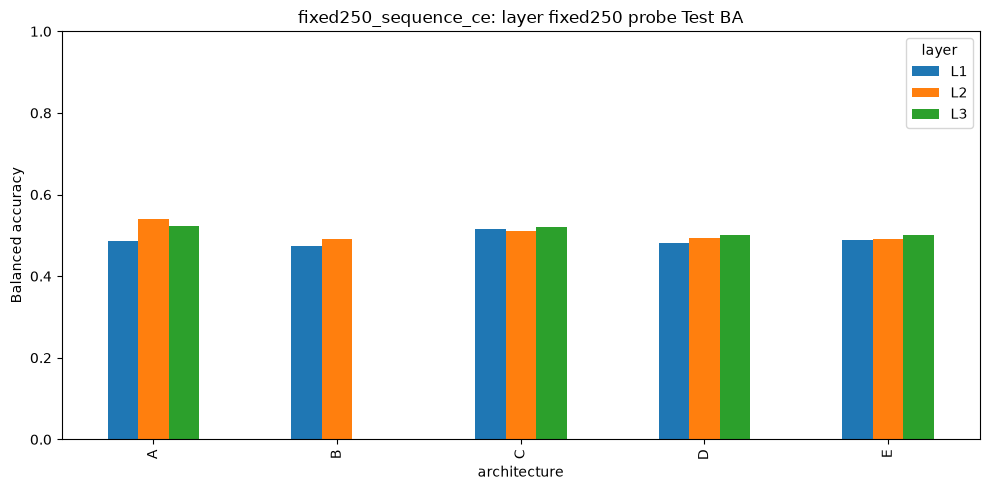

layer,L1,L2,L3
architecture,,,
A,0.449524,0.535240,0.503149
B,0.473677,0.530732,NaN
C,0.475380,0.534102,0.501744
D,0.468990,0.507282,0.522461
E,0.468822,0.492763,0.503543


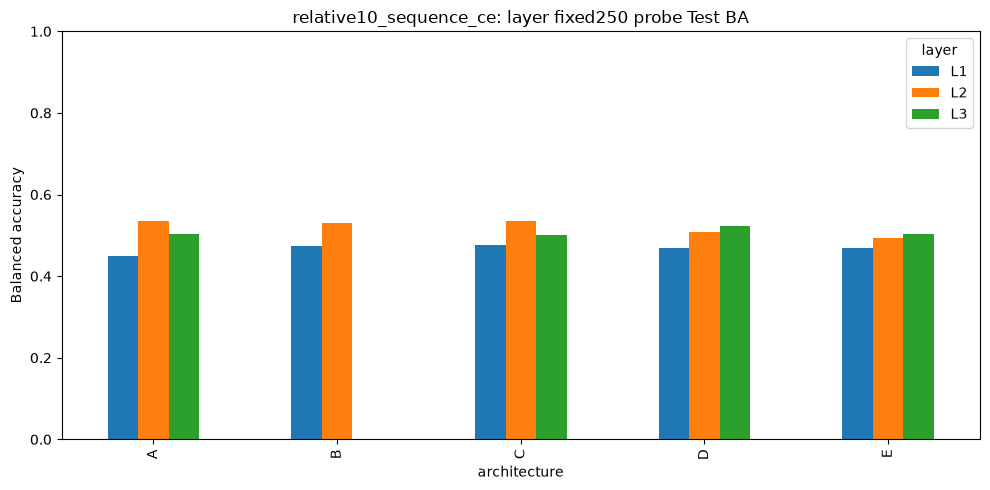

layer,L1,L2,L3
architecture,,,
A,0.516727,0.598060,0.507875
B,0.524996,0.625945,NaN
C,0.512275,0.591517,0.546346
D,0.530763,0.575573,0.524036
E,0.499588,0.548344,0.502979


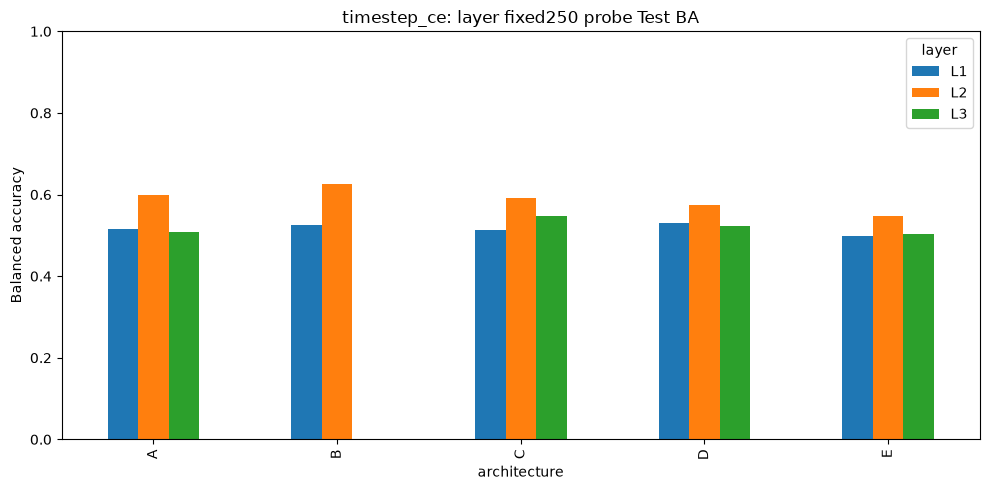

In [5]:
fixed = layer_probe_summary[layer_probe_summary['probe_type'] == 'fixed250'].copy()
for objective in fixed['objective'].unique():
    part = fixed[fixed['objective'] == objective]
    table = part.pivot(index='architecture', columns='layer', values='mean_probe_test_balanced_accuracy')
    display(table)
    ax = table.plot(kind='bar', figsize=(10,5))
    ax.set_title(f'{objective}: layer fixed250 probe Test BA')
    ax.set_ylabel('Balanced accuracy')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


## L3 preservation and native-readout utilization diagnostics

`last_minus_l2_fixed250_probe_ba` is L3 fixed250-probe BA minus L2 fixed250-probe BA for architectures with L3; negative means the third layer degraded linearly decodable temporal information. It is defined as zero for No-L3.

`readout_utilization_gap` is last-layer fixed250-probe BA minus native test BA.


,objective,architecture,last_layer,mean_l2_fixed250_probe_ba,mean_last_fixed250_probe_ba,mean_last_minus_l2_fixed250_probe_ba,mean_test_balanced_accuracy,mean_readout_utilization_gap
0,fixed250_sequence_ce,A,L3,0.541018,0.523881,-0.017137,0.490975,0.032906
1,fixed250_sequence_ce,B,L2,0.491647,0.491647,0.000000,0.497001,-0.005354
2,fixed250_sequence_ce,C,L3,0.510963,0.520090,0.009127,0.484216,0.035874
3,fixed250_sequence_ce,D,L3,0.492868,0.500419,0.007551,0.467756,0.032663
4,fixed250_sequence_ce,E,L3,0.492070,0.501391,0.009321,0.488971,0.012420
5,relative10_sequence_ce,A,L3,0.535240,0.503149,-0.032091,0.561331,-0.058181
6,relative10_sequence_ce,B,L2,0.530732,0.530732,0.000000,0.676388,-0.145656
7,relative10_sequence_ce,C,L3,0.534102,0.501744,-0.032359,0.600386,-0.098643
8,relative10_sequence_ce,D,L3,0.507282,0.522461,0.015179,0.617787,-0.095326
9,relative10_sequence_ce,E,L3,0.492763,0.503543,0.010780,0.584645,-0.081102


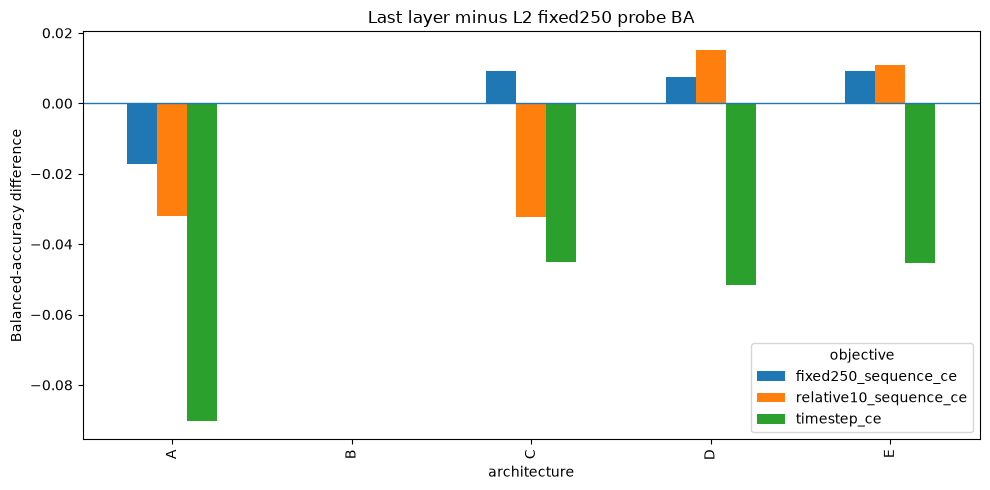

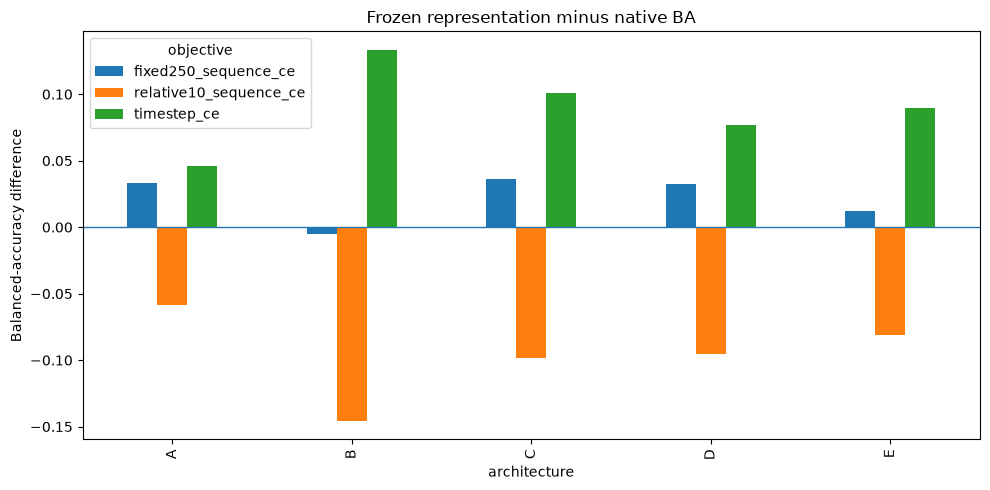

In [6]:
cols = [
    'objective','architecture','last_layer',
    'mean_l2_fixed250_probe_ba','mean_last_fixed250_probe_ba',
    'mean_last_minus_l2_fixed250_probe_ba','mean_test_balanced_accuracy',
    'mean_readout_utilization_gap'
]
display(diagnostic_summary[cols].sort_values(['objective','architecture']))
for metric, title in [
    ('mean_last_minus_l2_fixed250_probe_ba', 'Last layer minus L2 fixed250 probe BA'),
    ('mean_readout_utilization_gap', 'Frozen representation minus native BA'),
]:
    table = diagnostic_summary.pivot(index='architecture', columns='objective', values=metric)
    ax = table.plot(kind='bar', figsize=(10,5))
    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_ylabel('Balanced-accuracy difference')
    plt.tight_layout()
    plt.show()


## Tau-subgroup probes for multi-tau layers


In [7]:
sub_fixed = subgroup_probe_summary[subgroup_probe_summary['probe_type'] == 'fixed250'].copy()
display(sub_fixed.sort_values(['objective','architecture','layer','shift']))


,objective,architecture,last_layer,layer,shift,tau_syn_ms,group_neurons,probe_type,mean_feature_dim,mean_probe_val_balanced_accuracy,mean_probe_test_balanced_accuracy,mean_probe_test_macro_f1,mean_probe_test_accuracy,sd_feature_dim,sd_probe_val_balanced_accuracy,sd_probe_test_balanced_accuracy,sd_probe_test_macro_f1,sd_probe_test_accuracy
0,fixed250_sequence_ce,A,L3,L1,2,54.313430,43,fixed250,688.0,0.121362,0.122824,0.086038,0.125571,0.0,0.009533,0.043943,0.039907,0.049549
2,fixed250_sequence_ce,A,L3,L1,3,117.013683,43,fixed250,688.0,0.299892,0.293477,0.277866,0.301370,0.0,0.040476,0.041108,0.036221,0.044914
4,fixed250_sequence_ce,A,L3,L1,4,242.103471,42,fixed250,672.0,0.463217,0.470445,0.466277,0.481735,0.0,0.060641,0.067260,0.067553,0.073238
6,fixed250_sequence_ce,A,L3,L2,2,54.313430,43,fixed250,688.0,0.373341,0.416797,0.399980,0.424658,0.0,0.071331,0.041454,0.045757,0.041663
8,fixed250_sequence_ce,A,L3,L2,3,117.013683,43,fixed250,688.0,0.441306,0.530752,0.523748,0.538813,0.0,0.061119,0.050595,0.053561,0.045605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,timestep_ce,E,L3,L2,3,117.013683,43,fixed250,688.0,0.441021,0.503373,0.494873,0.513699,0.0,0.013493,0.026565,0.026156,0.023727
208,timestep_ce,E,L3,L2,4,242.103471,42,fixed250,672.0,0.482492,0.490450,0.484257,0.504566,0.0,0.024724,0.058338,0.062836,0.063641
210,timestep_ce,E,L3,L3,2,54.313430,43,fixed250,688.0,0.509067,0.509491,0.505774,0.520548,0.0,0.024394,0.052000,0.050350,0.059711
212,timestep_ce,E,L3,L3,3,117.013683,43,fixed250,688.0,0.479095,0.446276,0.436681,0.449772,0.0,0.023008,0.048818,0.051089,0.054937


## Whole-layer firing rates on test split


layer,L1,L2,L3
architecture,,,
A,0.015866,0.082438,0.227382
B,0.030406,0.239800,NaN
C,0.014368,0.065320,0.199675
D,0.014403,0.067059,0.196270
E,0.014001,0.064531,0.195574


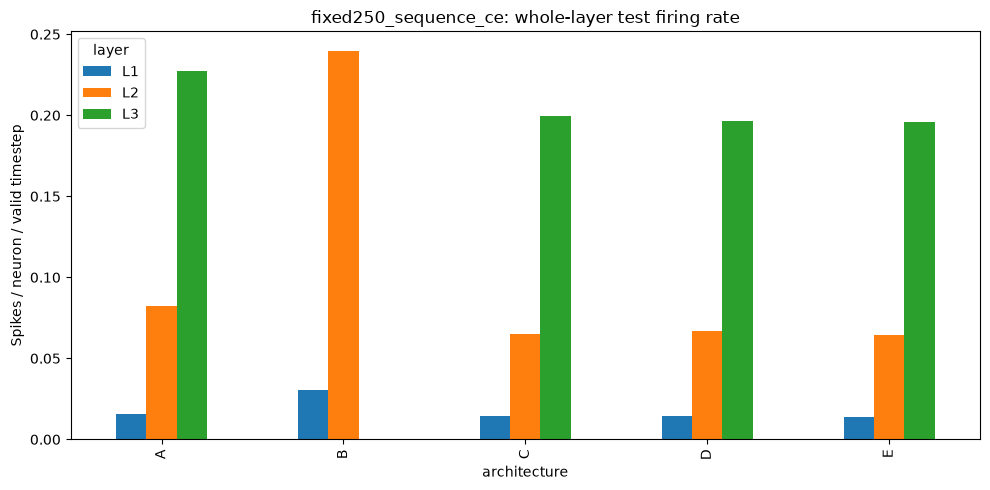

layer,L1,L2,L3
architecture,,,
A,0.017188,0.086275,0.233496
B,0.026963,0.227975,NaN
C,0.016250,0.073519,0.202799
D,0.016633,0.080444,0.232270
E,0.014215,0.064859,0.171386


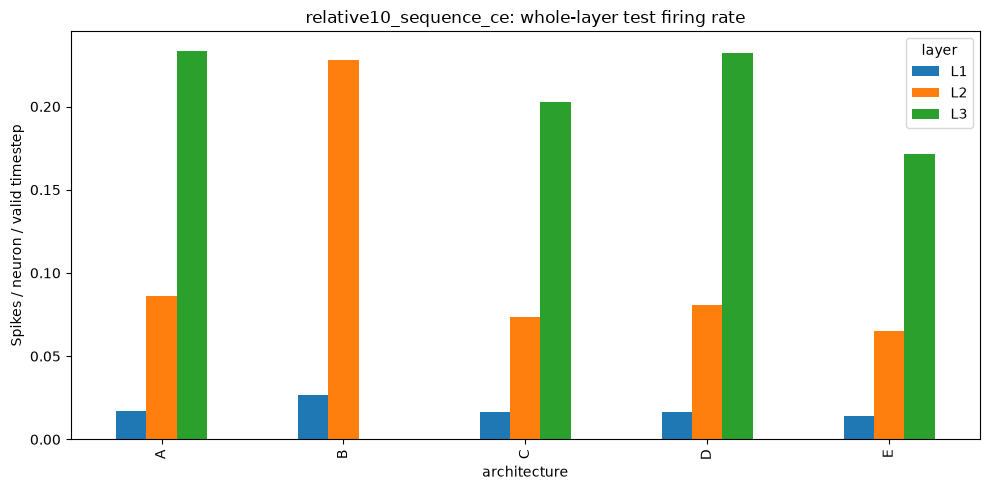

layer,L1,L2,L3
architecture,,,
A,0.022785,0.106526,0.330703
B,0.045506,0.268054,NaN
C,0.021521,0.101587,0.303815
D,0.023548,0.108348,0.341615
E,0.020363,0.095062,0.301205


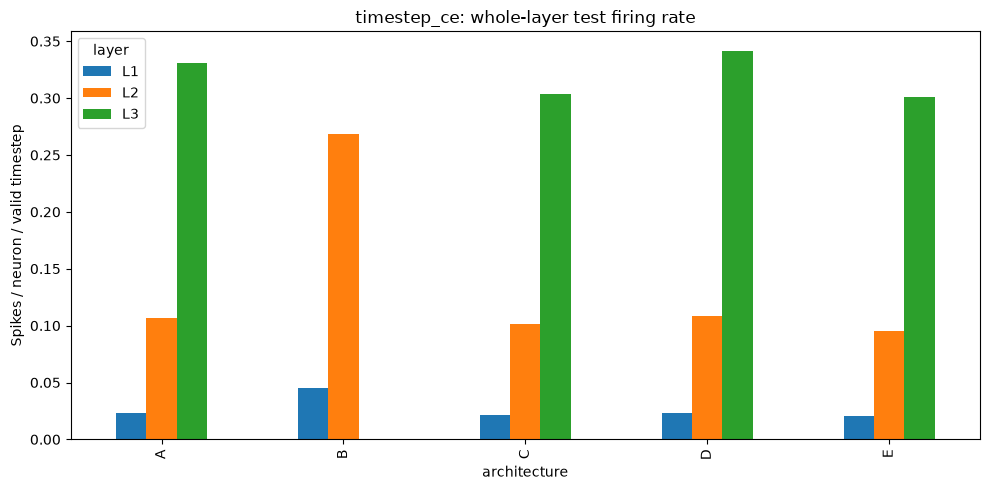

In [8]:
fr = firing_summary[(firing_summary['split'] == 'test') & (firing_summary['scope'] == 'whole_layer')].copy()
for objective in fr['objective'].unique():
    table = fr[fr['objective'] == objective].pivot(index='architecture', columns='layer', values='mean_firing_rate')
    display(table)
    ax = table.plot(kind='bar', figsize=(10,5))
    ax.set_title(f'{objective}: whole-layer test firing rate')
    ax.set_ylabel('Spikes / neuron / valid timestep')
    plt.tight_layout()
    plt.show()


## Validation BA trajectories


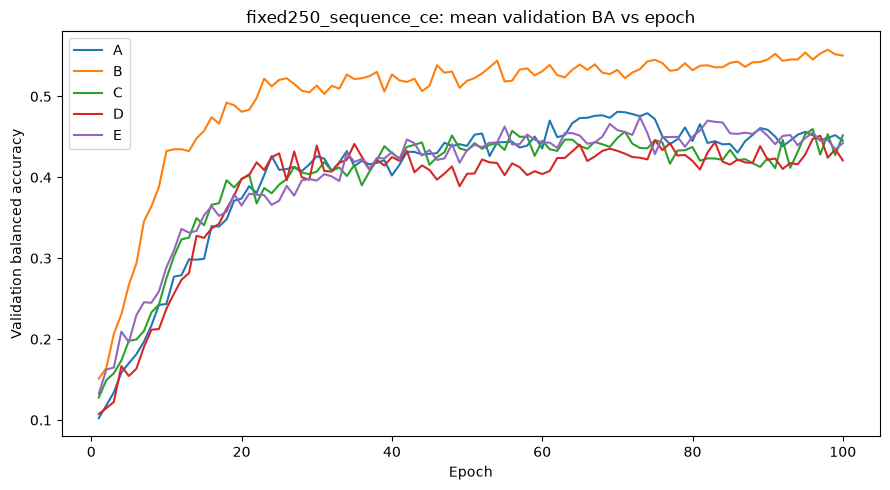

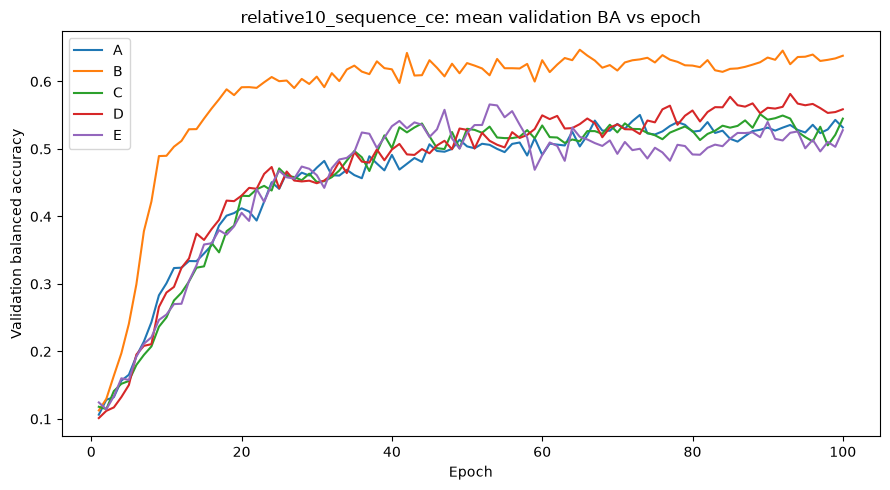

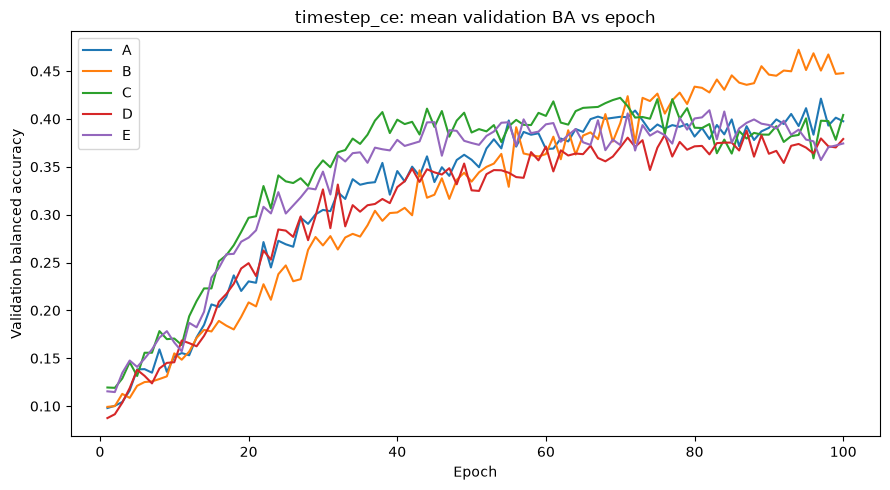

In [9]:
mean_history = history.groupby(['objective','architecture','epoch'], as_index=False)['val_balanced_accuracy'].mean()
for objective in mean_history['objective'].unique():
    part = mean_history[mean_history['objective'] == objective]
    fig, ax = plt.subplots(figsize=(9,5))
    for architecture, group in part.groupby('architecture'):
        ax.plot(group['epoch'], group['val_balanced_accuracy'], label=architecture)
    ax.set_title(f'{objective}: mean validation BA vs epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation balanced accuracy')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Rankings


In [10]:
display(native_summary.sort_values(['objective','mean_test_balanced_accuracy'], ascending=[True, False]))
display(diagnostic_summary.sort_values(['objective','mean_last_fixed250_probe_ba'], ascending=[True, False]))


,objective,architecture,last_layer,mean_test_balanced_accuracy,mean_test_macro_f1,mean_test_accuracy,mean_val_balanced_accuracy,mean_train_balanced_accuracy,mean_train_test_ba_gap,mean_best_epoch,sd_test_balanced_accuracy,sd_test_macro_f1,sd_test_accuracy,sd_val_balanced_accuracy,sd_train_balanced_accuracy,sd_train_test_ba_gap,sd_best_epoch
1,fixed250_sequence_ce,B,L2,0.497001,0.487383,0.511416,0.567188,0.992250,0.495249,80.333333,0.017805,0.021870,0.020925,0.033015,0.004891,0.021669,32.347076
0,fixed250_sequence_ce,A,L3,0.490975,0.486005,0.500000,0.507449,0.973263,0.482288,75.000000,0.020595,0.023635,0.018122,0.014174,0.012494,0.020190,5.291503
4,fixed250_sequence_ce,E,L3,0.488971,0.480764,0.495434,0.494671,0.969768,0.480798,72.666667,0.050932,0.055242,0.059053,0.035642,0.009260,0.057262,17.502381
2,fixed250_sequence_ce,C,L3,0.484216,0.470978,0.495434,0.474323,0.968515,0.484299,71.000000,0.008778,0.014417,0.017237,0.029110,0.004801,0.013112,22.113344
3,fixed250_sequence_ce,D,L3,0.467756,0.464878,0.474886,0.479600,0.898461,0.430704,59.333333,0.064736,0.063770,0.061390,0.022899,0.137589,0.072928,34.297716
6,relative10_sequence_ce,B,L2,0.676388,0.674993,0.687215,0.673567,0.985946,0.309558,61.666667,0.024585,0.029481,0.025931,0.030287,0.008173,0.032180,31.214313
8,relative10_sequence_ce,D,L3,0.617787,0.614481,0.623288,0.590320,0.965806,0.348020,76.666667,0.059671,0.070080,0.062775,0.037927,0.025298,0.059208,21.733231
7,relative10_sequence_ce,C,L3,0.600386,0.604642,0.611872,0.568226,0.973206,0.372820,86.000000,0.024490,0.022210,0.024054,0.005419,0.011732,0.013720,15.716234
9,relative10_sequence_ce,E,L3,0.584645,0.577123,0.584475,0.587935,0.953775,0.369130,63.333333,0.028615,0.025544,0.031636,0.008890,0.030596,0.009820,23.288051
5,relative10_sequence_ce,A,L3,0.561331,0.559372,0.570776,0.564873,0.976854,0.415524,80.000000,0.031037,0.023829,0.027681,0.019835,0.005075,0.034896,16.643317


,objective,architecture,last_layer,mean_l2_fixed250_probe_ba,mean_last_fixed250_probe_ba,mean_last_minus_l2_fixed250_probe_ba,mean_test_balanced_accuracy,mean_readout_utilization_gap,sd_l2_fixed250_probe_ba,sd_last_fixed250_probe_ba,sd_last_minus_l2_fixed250_probe_ba,sd_test_balanced_accuracy,sd_readout_utilization_gap
0,fixed250_sequence_ce,A,L3,0.541018,0.523881,-0.017137,0.490975,0.032906,0.053314,0.015747,0.040655,0.020595,0.005750
2,fixed250_sequence_ce,C,L3,0.510963,0.520090,0.009127,0.484216,0.035874,0.033175,0.053210,0.020283,0.008778,0.051124
4,fixed250_sequence_ce,E,L3,0.492070,0.501391,0.009321,0.488971,0.012420,0.078316,0.019954,0.060102,0.050932,0.051402
3,fixed250_sequence_ce,D,L3,0.492868,0.500419,0.007551,0.467756,0.032663,0.013580,0.019891,0.012038,0.064736,0.047899
1,fixed250_sequence_ce,B,L2,0.491647,0.491647,0.000000,0.497001,-0.005354,0.003816,0.003816,0.000000,0.017805,0.017328
6,relative10_sequence_ce,B,L2,0.530732,0.530732,0.000000,0.676388,-0.145656,0.033262,0.033262,0.000000,0.024585,0.049554
8,relative10_sequence_ce,D,L3,0.507282,0.522461,0.015179,0.617787,-0.095326,0.039327,0.079713,0.077241,0.059671,0.022370
9,relative10_sequence_ce,E,L3,0.492763,0.503543,0.010780,0.584645,-0.081102,0.042410,0.013304,0.053985,0.028615,0.032662
5,relative10_sequence_ce,A,L3,0.535240,0.503149,-0.032091,0.561331,-0.058181,0.023916,0.024811,0.001173,0.031037,0.034826
7,relative10_sequence_ce,C,L3,0.534102,0.501744,-0.032359,0.600386,-0.098643,0.020091,0.041072,0.033312,0.024490,0.058464
